## AUTHORS: MICHAEL DINH SID 199215519 FAWAZ OUAIDA SID 530593715
**PART A:** CRITICAL ANALYSIS OF SELECTED PAPER AND LITERATURE REVIEW
PAPER: Moreno-Sánchez PA, Aalto M, van Gils M. Prediction of patient flow in the emergency department using explainable artificial intelligence. DIGITAL HEALTH. 2024;10. doi:10.1177/20552076241264194

**PART B** DATA EXPERIMENT REPORT
TITLE: Refining the prediction of inpatient admission from emergency departments using MIMIC-IV-ED: A machine learning analysis.

## Licenses
MIMIC IV ED data was licensed from Physionet for the collaborators's access, as such cannot be shared in a public repository.

## Resources

This notebook utilizes several key Python libraries for data processing, machine learning, and visualization:

**Pandas (pandas)**: Used for tabular data manipulation and analysis. In the code, it filters the datasets (raw_df['hadm_id'].notna()), calculates summary statistics (value_counts()), and handles chronological sorting and indexing to isolate the latest patient visits.   
**Matplotlib (matplotlib.pyplot)**: A foundational data visualization library. It is used to initialize the plot figures, define axis labels, set titles, draw the perfect calibration reference line, and render the final visualizations (e.g., plt.show()).   
**Seaborn (seaborn)**: A statistical data visualization library built on top of Matplotlib. It provides a simpler interface for styling graphics and is used specifically to generate the bar chart (sns.barplot) of admitted stays per disposition type.   
**Scikit-learn (sklearn)**: A comprehensive machine learning library used for data splitting, modeling, and evaluation. The code utilizes several of its modules:   
* model_selection.train_test_split: Partitions the data into
training and testing sets, ensuring balanced class distributions via the stratify parameter.
* ensemble.AdaBoostClassifier: Initializes and trains the baseline AdaBoost model.
* metrics: Imports functions like accuracy_score, roc_auc_score, classification_report, and f1_score to mathematically evaluate model performance.   
* calibration.calibration_curve: Calculates the true positive fractions versus predicted probabilities to build the reliability diagram.

**XGBoost (xgboost):** An optimized gradient boosting framework designed for high performance. The XGBClassifier module is used to initialize, train, and generate predictions for both the binary admission model and the multiclass care unit model.   
**NumPy (numpy):** A core library for numerical computing and array operations. It is used during the multiclass classification step to extract the unique care unit classes and encode them into numerical formats (np.unique(..., return_inverse=True)).   
**shap**: For explainable AI, specifically SHAP (SHapley Additive exPlanations) values to interpret model predictions.

**matplotlib** : For creating static, interactive, and animated visualizations in Python.

**Regular Expression(re)**: powerful tools for searching, splitting, and manipulating text based on specific patterns rather than exact word matches.

## Computational Environment
This notebook was coded and tested intechangeably by:
* Google Colab(T4 runtime) assited by Gemini Pro
* VSC running python 3.14.6. assisted by Github Colab (gpt luna 5.6, gpt terra 5.6)

##Data Location
Data for this analysis is located in Google Drive at the path `/content/drive/MyDrive/5005/A1', which contains the CSV files of  relevant MIMIC-IV ED dataset v2.2; unfortunately cannot be shared in a public folder due to licensing constainsts.


In [1]:
# ---------------------------------------------------------------------------
# Import Libraries (55s typical run time colab T4)
# ---------------------------------------------------------------------------

import os
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from xgboost import XGBClassifier

# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------------------------
# Environment Setup
# ---------------------------------------------------------------------------
# mount google drive, DIrectory for data and output files : /5005/A1
# Use the local dataset directory.
data_dir = Path("/content/drive/MyDrive/5005/A1")

# ---------------------------------------------------------------------------
# 0) Configuration & Reproducibility Setup
# ---------------------------------------------------------------------------
# Define the file path for saving the final joined dataset.
out_file = data_dir / "mimic_iv_ed_v22_joined.csv"

# Set a global random state seed to ensure consistent, reproducible results.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ==========================================
# 1) Loading Data Files
# ==========================================
print("Loading data and creating aggregate data sets...")

# 1. Load core ED stays and triage tables
ed_stays = pd.read_csv(os.path.join(data_dir, "ed_stays.csv"))
triage = pd.read_csv(os.path.join(data_dir, "triage.csv"))
print("ed_stays"); display(ed_stays.head())
print("triage"); display(triage.head())

# Load patient demographics restricting to specific columns to optimize memory.
demo_cols = ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
patients = pd.read_csv(os.path.join(data_dir, 'patient_demographics.csv'), usecols=demo_cols)
print("patients"); display(patients.head())

# ==========================================
# 2. Load and Aggregate One-to-Many Tables
# ==========================================

# Vitals: Assume continuous monitoring, take the mean per stay_id
vitals = pd.read_csv(os.path.join(data_dir, "vitals.csv"))
vitals_agg = vitals.groupby('stay_id').mean(numeric_only=True).add_prefix('mean_')
print("vitals"); display(vitals.head(), vitals_agg.head())
# skipped rythm and pain as they are not numeric, *** explore ways to readd

# ED Diagnosis: Count total diagnoses per stay
ed_diagnosis = pd.read_csv(os.path.join(data_dir, "ed_diagnosis.csv"))
diag_agg = ed_diagnosis.groupby('stay_id').size().reset_index(name='total_diagnoses')
print("ed_diagnosis"); display(ed_diagnosis.head())
print("diag_agg"); display(diag_agg.head())

# Medrecon: Create binary flags if the patient had records in these tables
medrecon = pd.read_csv(os.path.join(data_dir, "medrecon.csv"))
medrecon_agg = medrecon[['stay_id']].drop_duplicates()
medrecon_agg['has_medrecon'] = 1
print("medrecon_agg"); display(medrecon.head(), medrecon_agg.head())

# Same for Pyxis: Create binary flags if the patient had records in these tables
pyxis = pd.read_csv(os.path.join(data_dir, "pyxis.csv"))
pyxis_agg = pyxis[['stay_id']].drop_duplicates()
pyxis_agg['has_pyxis_meds'] = 1
print("pyxis"); display(pyxis.head(), pyxis_agg.head())


Mounted at /content/drive
Loading data and creating aggregate data sets...
ed_stays


,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10000032,22595853.0,33258284,6/05/2180 19:17,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED
1,10000032,22841357.0,38112554,26/06/2180 15:54,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED
2,10000032,25742920.0,35968195,5/08/2180 20:58,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED
3,10000032,29079034.0,32952584,22/07/2180 16:24,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME
4,10000032,29079034.0,39399961,23/07/2180 5:54,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED


triage


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint
0,10000032,32952584,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension
1,10000032,33258284,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention"
2,10000032,35968195,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain"
3,10000032,38112554,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention
4,10000032,39399961,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC"


patients


...

,subject_id,stay_id,charttime,name,gsn,ndc,etc_rn,etccode,etcdescription
0,10000032,32952584,22/07/2180 17:26,albuterol sulfate,28090,21695042308,1,5970.0,Asthma/COPD Therapy - Beta 2-Adrenergic Agents...
1,10000032,32952584,22/07/2180 17:26,calcium carbonate,1340,10135021101,1,733.0,Minerals and Electrolytes - Calcium Replacement
2,10000032,32952584,22/07/2180 17:26,cholecalciferol (vitamin D3),65241,37205024678,1,670.0,Vitamins - D Derivatives
3,10000032,32952584,22/07/2180 17:26,emtricitabine-tenofovir [Truvada],57883,35356007003,1,5849.0,Antiretroviral - Nucleoside and Nucleotide Ana...
4,10000032,32952584,22/07/2180 17:26,fluticasone [Flovent HFA],21251,49999061401,1,371.0,Asthma Therapy - Inhaled Corticosteroids (Gluc...


,stay_id,has_medrecon
0,32952584,1
14,33258284,1
24,35968195,1
31,38112554,1
44,39399961,1


pyxis


,subject_id,stay_id,charttime,med_rn,name,gsn_rn,gsn
0,10000032,32952584,22/07/2180 17:59,1,Albuterol Inhaler,1,5037.0
1,10000032,32952584,22/07/2180 17:59,1,Albuterol Inhaler,2,28090.0
2,10000032,35968195,5/08/2180 22:29,1,Morphine,1,4080.0
3,10000032,35968195,5/08/2180 22:55,2,Donnatol (Elixir),1,4773.0
4,10000032,35968195,5/08/2180 22:55,3,Aluminum-Magnesium Hydrox.-Simet,1,2701.0


,stay_id,has_pyxis_meds
0,32952584,1
2,35968195,1
8,38112554,1
11,39399961,1
25,35203156,1


In [2]:
# ==========================================
# 3. Merge Everything Together (17s run time T4)
# ==========================================

print("Merging tables...")

# Base merge: stays + demographics
df = ed_stays.merge(patients, on='subject_id', how='left')
display(df.head())

# Compute approximate age at time of ED visit: Age = anchor_age + (visit_year - anchor_year)
# Example, When a patient's visit year matches their anchor year, the temporal difference in your formula becomes zero:
df['intime'] = pd.to_datetime(df['intime'], dayfirst=True)

df['age'] = df['anchor_age'] + (df['intime'].dt.year - df['anchor_year'])

pd.set_option('display.max_rows', 100)
display(df.head(20))

# Merge with triage and aggregated tables
df = df.merge(triage, on='stay_id', how='left')
df = df.merge(vitals_agg, on='stay_id', how='left')
df = df.merge(diag_agg, on='stay_id', how='left')
df = df.merge(medrecon_agg, on='stay_id', how='left')
df = df.merge(pyxis_agg, on='stay_id', how='left')

# Fill missing values for the new aggregated flags
df['total_diagnoses'] = df['total_diagnoses'].fillna(0)
df['has_medrecon'] = df['has_medrecon'].fillna(0)
df['has_pyxis_meds'] = df['has_pyxis_meds'].fillna(0)

# 4. Create Targets
# Binary Target: Hospital Admission
df['admission'] = df['hadm_id'].notna().astype(int)

# Multiclass Target: Disposition Ward (careunit)
ward_mapping = {'ADMITTED': 'General', 'TRANSFER': 'General',
        'OBSERVATION': 'Observational',
        'CARDIOLOGY': 'Cardiology',
        'ICU': 'ICU',
        'SURGICAL': 'Surgical',
        'NEUROLOGY': 'Neurology',
        'OBSTETRICS': 'Obstetrics',
        'ONCOLOGY': 'Oncology'}

def map_ward(disposition):
  if pd.isna(disposition):
    return 'General'
  disp_str = str(disposition).upper()
  for key, val in ward_mapping.items():
    if key in disp_str:
      return val
      return 'General'

df['careunit'] = df['disposition'].apply(map_ward)

pd.set_option('display.max_rows', 50)
display(df.head(10))
df.to_csv(data_dir / "mimic_iv_ed_processed.csv", index=False)

raw_df = df # Assign to raw_df as used in previous cell
pd.set_option('display.max_columns', None)
display(raw_df.head(10))

Merging tables...


,subject_id,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,22595853.0,33258284,6/05/2180 19:17,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180
1,10000032,22841357.0,38112554,26/06/2180 15:54,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180
2,10000032,25742920.0,35968195,5/08/2180 20:58,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180
3,10000032,29079034.0,32952584,22/07/2180 16:24,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180
4,10000032,29079034.0,39399961,23/07/2180 5:54,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180


,subject_id,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72
7,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25
8,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25
9,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25


,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,...,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,...,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,...,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,...,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,...,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,...,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,...,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,...,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None
7,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,...,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None
8,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,...,66.000000,15.000000,100.000000,111.000000,62.000000,1.0,0.0,0.0,0,None
9,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,...,64.000000,18.000000,98.000000,109.000000,69.000000,1.0,0.0,1.0,0,None


,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age,subject_id_y,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,mean_subject_id,mean_temperature,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.40,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",10000032.0,97.700000,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.90,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,10000032.0,97.900000,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,99.40,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",10000032.0,98.300000,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52,10000032,97.80,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,10000032.0,98.300000,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.70,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",10000032.0,98.550000,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72,10000084,97.50,78.0,16.0,100.0,114.0,71.0,0,2.0,"Confusion, Hallucinations",10000084.0,97.833333,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72,10000084,98.70,80.0,16.0,95.0,111.0,72.0,0,2.0,"Altered mental status, B Pedal edema",10000084.0,98.300000,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None
7,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,98.0,16.0,100.0,135.0,85.0,5,3.0,"LEFT CHEEK SWELLING, Abscess",10000108.0,98.500000,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None
8,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.21,83.0,20.0,100.0,112.0,81.0,5,3.0,L CHEEK ABSCESS,10000108.0,98.200000,66.000000,15.000000,100.000000,111.000000,62.000000,1.0,0.0,0.0,0,None
9,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,101.0,18.0,100.0,131.0,62.0,5,3.0,L FACIAL SWELLING,10000108.0,98.400000,64.000000,18.000000,98.000000,109.000000,69.000000,1.0,0.0,1.0,0,None


In [3]:
# ============================================================================================================
# 3.1 encode chiefcomplaint free text field into a categorised new field called PRESENTING_PROB (14s runtime T4)
# ============================================================================================================
import re

# 1. Define regex patterns for categorizing chief complaints
presenting_problem_patterns = [
    ("Abdominal pain", re.compile(r"\b(?:abd|abdominal|rlq|llq|ruq|luq|epigastric)\b|\bflank pain\b")),
    ("Chest pain", re.compile(r"\b(?:chest pain|cp)\b")),
    ("Respiratory", re.compile(r"\b(?:dyspnea|sob|shortness of breath|cough|asthma|wheez|hypoxia|respiratory|ili)\b")),
    ("Trauma or injury", re.compile(r"\b(?:s/p fall|fall|mvc|assault|trauma|injury|fracture|laceration|head injury|burn)\b")),
    ("Neurological", re.compile(r"\b(?:headache|seizure|altered mental status|ams|confusion|stroke|cva|neuro)\b")),
    ("Dizziness or syncope", re.compile(r"\b(?:dizziness|syncope|near syncope|weakness|lightheaded)\b")),
    ("Mental health or substance use", re.compile(r"\b(?:si|suicidal|depression|anxiety|psych|etoh|alcohol|overdose|substance|detox)\b")),
    ("Infection or fever", re.compile(r"\b(?:fever|infection|sepsis|chills)\b")),
    ("Gastrointestinal symptoms", re.compile(r"\b(?:n/v|nausea|vomiting|diarrhea|brbpr|gi bleed|rectal bleeding|constipation)\b")),
    ("Genitourinary", re.compile(r"\b(?:dysuria|hematuria|urinary|retention|kidney|renal|testicular)\b")),
    ("Obstetric or gynecological", re.compile(r"\b(?:vaginal|pregnan|pelvic|ob|gyn)\b")),
    ("Cardiovascular", re.compile(r"\b(?:palpitations|hypertension|hypotension|tachycardia|bradycardia)\b")),
    ("Skin or wound", re.compile(r"\b(?:wound|rash|cellulitis|abscess|skin)\b")),
    ("ENT, eye, or dental", re.compile(r"\b(?:sore throat|eye|vision|ear|dental|tooth|nose|epistaxis)\b")),
    ("Abnormal labs or tests", re.compile(r"\b(?:abnormal labs|lab|hyperglycemia|hypoglycemia)\b")),
    ("Transfer or administrative", re.compile(r"\b(?:transfer|med refill|medical clearance)\b")),
]

# 2. Define the categorization function
def categorise_presenting_problem(chiefcomplaint):
    """Categorizes the primary chief complaint into a standardized bucket."""
    if pd.isna(chiefcomplaint):
        return "Unknown"

    # Extract the first complaint if multiple are listed (separated by commas)
    first_problem = str(chiefcomplaint).split(",", 1)[0].strip().lower()

    if first_problem in {"", "___", "nan", "none"}:
        return "Unknown"

    # Match against the defined regex patterns
    for category, pattern in presenting_problem_patterns:
        if pattern.search(first_problem):
            return category
    return "Other"

# 3. Apply the categorization directly to the main dataframe (df)
# The 'chiefcomplaint' column was brought over when df.merge(triage) was executed previously.
df["PRESENTING_PROB"] = df["chiefcomplaint"].apply(categorise_presenting_problem)

# 4. Display the results
display(df[["chiefcomplaint", "PRESENTING_PROB"]].head(10))
display(df["PRESENTING_PROB"].value_counts(dropna=False))
display(df.head(10))
df.to_csv("5005A1-merged-dataset.csv", index=False)

,chiefcomplaint,PRESENTING_PROB
0,"Abd pain, Abdominal distention",Abdominal pain
1,Abdominal distention,Abdominal pain
2,"n/v/d, Abd pain",Gastrointestinal symptoms
3,Hypotension,Cardiovascular
4,"Abdominal distention, Abd pain, LETHAGIC",Abdominal pain
5,"Confusion, Hallucinations",Neurological
6,"Altered mental status, B Pedal edema",Neurological
7,"LEFT CHEEK SWELLING, Abscess",Other
8,L CHEEK ABSCESS,Skin or wound
9,L FACIAL SWELLING,Other


,count
PRESENTING_PROB,
Other,127973
Abdominal pain,52721
Trauma or injury,39903
Respiratory,28709
Chest pain,27723
Mental health or substance use,25082
Neurological,22551
Dizziness or syncope,19427
Gastrointestinal symptoms,17802


,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age,subject_id_y,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,mean_subject_id,mean_temperature,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit,PRESENTING_PROB
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.40,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",10000032.0,97.700000,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General,Abdominal pain
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.90,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,10000032.0,97.900000,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General,Abdominal pain
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,99.40,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",10000032.0,98.300000,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General,Gastrointestinal symptoms
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52,10000032,97.80,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,10000032.0,98.300000,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None,Cardiovascular
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.70,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",10000032.0,98.550000,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General,Abdominal pain
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72,10000084,97.50,78.0,16.0,100.0,114.0,71.0,0,2.0,"Confusion, Hallucinations",10000084.0,97.833333,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General,Neurological
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72,10000084,98.70,80.0,16.0,95.0,111.0,72.0,0,2.0,"Altered mental status, B Pedal edema",10000084.0,98.300000,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None,Neurological
7,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,98.0,16.0,100.0,135.0,85.0,5,3.0,"LEFT CHEEK SWELLING, Abscess",10000108.0,98.500000,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None,Other
8,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.21,83.0,20.0,100.0,112.0,81.0,5,3.0,L CHEEK ABSCESS,10000108.0,98.200000,66.000000,15.000000,100.000000,111.000000,62.000000,1.0,0.0,0.0,0,None,Skin or wound
9,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,101.0,18.0,100.0,131.0,62.0,5,3.0,L FACIAL SWELLING,10000108.0,98.400000,64.000000,18.000000,98.000000,109.000000,69.000000,1.0,0.0,1.0,0,None,Other


In [4]:
###################################################################################################################
# 4. Perform Exploratory Data Analysis (EDA) on categorical variables with counts and percentages (0s runtime T4)
###################################################################################################################
# run once !pip install -U ipykernel

categorical_columns = ['gender_x', 'gender_y', 'race', 'arrival_transport', 'admission', 'PRESENTING_PROB']

for column in categorical_columns:
    category_counts = df[column].value_counts(dropna=False)
    category_summary = pd.DataFrame({
        'count': category_counts,
        'percentage': (category_counts / len(df) * 100).round(1),
    })

    category_summary['percentage'] = category_summary['percentage'].map('{:.1f}%'.format)

    print(f'\n{column}')

    display(category_summary)


gender_x


,count,percentage
gender_x,,
F,229898,54.1%
M,195189,45.9%



gender_y


,count,percentage
gender_y,,
F,229912,54.1%
M,195175,45.9%



race


...

,count,percentage
arrival_transport,,
WALK IN,251849,59.2%
AMBULANCE,155752,36.6%
UNKNOWN,15352,3.6%
OTHER,1266,0.3%
HELICOPTER,868,0.2%



admission


,count,percentage
admission,,
0,222071,52.2%
1,203016,47.8%



PRESENTING_PROB


,count,percentage
PRESENTING_PROB,,
Other,127973,30.1%
Abdominal pain,52721,12.4%
Trauma or injury,39903,9.4%
Respiratory,28709,6.8%
Chest pain,27723,6.5%
Mental health or substance use,25082,5.9%
Neurological,22551,5.3%
Dizziness or syncope,19427,4.6%
Gastrointestinal symptoms,17802,4.2%


In [5]:
# ==========================================
# 5. Feature Engineering (Integrated) (4s T4)
# ==========================================
print("Engineering features...")

# Sort chronologically per patient for historical features
raw_df = raw_df.sort_values(by=['subject_id_x', 'intime']).reset_index(drop=True)

raw_df['nth_stay'] = raw_df.groupby('subject_id_x').cumcount() + 1
raw_df['admissions_before'] = raw_df.groupby('subject_id_x')['admission'].cumsum() - raw_df['admission']

raw_df['admission_ratio'] = np.where(
    raw_df['nth_stay'] > 1,
    raw_df['admissions_before'] / (raw_df['nth_stay'] - 1),
    0.0
)

raw_df['month'] = raw_df['intime'].dt.strftime('%B')
raw_df['weekday'] = raw_df['intime'].dt.strftime('%A')

def time_to_slot(hour):
    if 0 <= hour < 4: return '0-4'
    elif 4 <= hour < 8: return '4-8'
    elif 8 <= hour < 12: return '8-12'
    elif 12 <= hour < 16: return '12-16'
    elif 16 <= hour < 20: return '16-20'
    else: return '20-24'

raw_df['time_slot'] = raw_df['intime'].dt.hour.apply(time_to_slot)
raw_df['pain_clean'] = pd.to_numeric(raw_df['pain'], errors='coerce')

df_engineered = raw_df # Assign to df_engineered for the next step

# Updated feature arrays to include the new aggregated columns
NUMERICAL_COLS = [
    'age', 'temperature', 'heartrate', 'resprate', 'sbp', 'dbp',
    'admission_ratio', 'admissions_before', 'nth_stay',
    'total_diagnoses', 'has_medrecon', 'has_pyxis_meds'
]
ORDINAL_COLS = ['acuity', 'pain_clean']
NOMINAL_COLS = ['arrival_transport', 'gender', 'month', 'weekday', 'time_slot']

display(raw_df.head(10))

Engineering features...


,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age,subject_id_y,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,mean_subject_id,mean_temperature,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit,PRESENTING_PROB,nth_stay,admissions_before,admission_ratio,month,weekday,time_slot,pain_clean
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.40,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",10000032.0,97.700000,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General,Abdominal pain,1,0,0.0,May,Saturday,16-20,0.0
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.90,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,10000032.0,97.900000,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General,Abdominal pain,2,1,1.0,June,Monday,12-16,10.0
2,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52,10000032,97.80,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,10000032.0,98.300000,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None,Cardiovascular,3,2,1.0,July,Saturday,16-20,7.0
3,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.70,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",10000032.0,98.550000,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General,Abdominal pain,4,3,1.0,July,Sunday,4-8,13.0
4,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,99.40,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",10000032.0,98.300000,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General,Gastrointestinal symptoms,5,4,1.0,August,Saturday,20-24,10.0
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72,10000084,97.50,78.0,16.0,100.0,114.0,71.0,0,2.0,"Confusion, Hallucinations",10000084.0,97.833333,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General,Neurological,1,0,0.0,November,Thursday,20-24,0.0
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72,10000084,98.70,80.0,16.0,95.0,111.0,72.0,0,2.0,"Altered mental status, B Pedal edema",10000084.0,98.300000,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None,Neurological,2,1,1.0,December,Saturday,16-20,0.0
7,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.21,83.0,20.0,100.0,112.0,81.0,5,3.0,L CHEEK ABSCESS,10000108.0,98.200000,66.000000,15.000000,100.000000,111.000000,62.000000,1.0,0.0,0.0,0,None,Skin or wound,1,0,0.0,September,Friday,16-20,5.0
8,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,101.0,18.0,100.0,131.0,62.0,5,3.0,L FACIAL SWELLING,10000108.0,98.400000,64.000000,18.000000,98.000000,109.000000,69.000000,1.0,0.0,1.0,0,None,Other,2,0,0.0,September,Saturday,16-20,5.0
9,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,98.0,16.0,100.0,135.0,85.0,5,3.0,"LEFT CHEEK SWELLING, Abscess",10000108.0,98.500000,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None,Other,3,0,0.0,September,Tuesday,16-20,5.0


In [6]:
# =========================================================
# 6. Outlier Removal & Preprocessing (Integrated) (1s T4)
# =========================================================
print("Preprocessing data and handling outliers...")

mask = pd.Series(True, index=df_engineered.index)
for col in NUMERICAL_COLS:
    if col in df_engineered.columns:
        Q1 = df_engineered[col].quantile(0.25)
        Q3 = df_engineered[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        mask = mask & ((df_engineered[col].isna()) | ((df_engineered[col] >= lower_bound) & (df_engineered[col] <= upper_bound)))

df_clean = df_engineered[mask].copy()

# Ensure columns exist before processing
existing_num_cols = [c for c in NUMERICAL_COLS if c in df_clean.columns]
existing_ord_cols = [c for c in ORDINAL_COLS if c in df_clean.columns]
existing_cat_cols = [c for c in NOMINAL_COLS if c in df_clean.columns]

# 1. Numerical
num_imputer = SimpleImputer(strategy='mean')
scaler = MinMaxScaler()
X_num = num_imputer.fit_transform(df_clean[existing_num_cols])
X_num_scaled = scaler.fit_transform(X_num)
df_num_processed = pd.DataFrame(X_num_scaled, columns=existing_num_cols, index=df_clean.index)

# 2. Ordinal
ord_imputer = SimpleImputer(strategy='most_frequent')
X_ord = ord_imputer.fit_transform(df_clean[existing_ord_cols])
df_ord_processed = pd.DataFrame(X_ord, columns=existing_ord_cols, index=df_clean.index)

# 3. Nominal
cat_imputer = SimpleImputer(strategy='most_frequent')
X_cat_imp = cat_imputer.fit_transform(df_clean[existing_cat_cols])
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_ohe = ohe.fit_transform(X_cat_imp)
ohe_cols = ohe.get_feature_names_out(existing_cat_cols)
df_cat_processed = pd.DataFrame(X_cat_ohe, columns=ohe_cols, index=df_clean.index)

X = pd.concat([df_num_processed, df_ord_processed, df_cat_processed], axis=1)
y_admission = df_clean['admission']
y_careunit = df_clean['careunit']

# output_path_X = data_dir / "X_features_processed.csv"
# X.to_csv(output_path_X, index=False)


Preprocessing data and handling outliers...


In [7]:
# ====================================================================================================
# 7. Model Training and Evaluation (Integrated) XGBoost and AdaBoost 30% split for test data (29s T4)
# ====================================================================================================
print("\n==========================================")
print("TASK 7.1: Binary Hospital Admission Prediction")
print("============================================")

X_train_adm, X_test_adm, y_train_adm, y_test_adm = train_test_split(
    X, y_admission, test_size=0.30, random_state=RANDOM_STATE, stratify=y_admission
)

xgb_adm = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_adm.fit(X_train_adm, y_train_adm)
print(f"[XGBoost] Admission Accuracy: {accuracy_score(y_test_adm, xgb_adm.predict(X_test_adm)):.4f}")
print(f"[XGBoost] Admission AUROC:    {roc_auc_score(y_test_adm, xgb_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

ada_adm = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
ada_adm.fit(X_train_adm, y_train_adm)
print(f"[AdaBoost] Admission Accuracy: {accuracy_score(y_test_adm, ada_adm.predict(X_test_adm)):.4f}")
print(f"[AdaBoost] Admission AUROC:    {roc_auc_score(y_test_adm, ada_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

print("\n================================================")
print("TASK 7.2: Multiclass Disposition Ward Prediction")
print("==================================================")

admitted_idx = y_admission[y_admission == 1].index
X_res = X.loc[admitted_idx]
y_res = y_careunit.loc[admitted_idx]

unique_careunits = y_res.nunique()
print(f"Unique values in y_res for admitted patients: {y_res.value_counts()}")

if unique_careunits < 2:
    print("Skipping multiclass classification: Not enough unique careunit classes for admitted patients.")
else:
    labels, y_res_encoded = np.unique(y_res, return_inverse=True)

    X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
        X_res, y_res_encoded, test_size=0.30, random_state=RANDOM_STATE, stratify=y_res_encoded
    )

    xgb_res = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, objective='multi:softprob', eval_metric='mlogloss', random_state=RANDOM_STATE)
    xgb_res.fit(X_train_res, y_train_res)
    print(f"[XGBoost] Resource Macro F1: {f1_score(y_test_res, xgb_res.predict(X_test_res), average='macro'):.4f}")
    print(f"[XGBoost] Resource AUROC:    {roc_auc_score(y_test_res, xgb_res.predict_proba(X_test_res), multi_class='ovr'):.4f}")


TASK 1: Binary Hospital Admission Prediction
[XGBoost] Admission Accuracy: 0.7625
[XGBoost] Admission AUROC:    0.8436
[AdaBoost] Admission Accuracy: 0.7442
[AdaBoost] Admission AUROC:    0.8219

TASK 2: Multiclass Disposition Ward Prediction
Unique values in y_res for admitted patients: careunit
General    135591
Name: count, dtype: int64
Skipping multiclass classification: Not enough unique careunit classes for admitted patients.


In [8]:
# ===================================================================================================================
# 8.1 Classifier performance comparative Training, Cross-Validation & Table 4 Generation comparing classifiers
# RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
# and Standard deviation ()values ; (22 minutes T4)
# ===================================================================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import pandas as pd

print("\n==============================================")
print("Binary Hospital Admission Prediction (Table 4)")
print("==============================================")

# 1. Train / Test Split (70/30 Stratified Split)
X_train_adm, X_test_adm, y_train_adm, y_test_adm = train_test_split(
    X, y_admission, test_size=0.30, random_state=RANDOM_STATE, stratify=y_admission
)

# 2. Define Base Classifiers
base_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "Extra trees": ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
}

# 3. Define Ensemble Voting Classifier (Soft Voting)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', base_models["Random Forest"]),
        ('gb', base_models["Gradient Boosting"]),
        ('xgb', base_models["XGBoost"])
    ],
    voting='soft'
)

# Combine all models into a single dictionary
classifiers = {**base_models, "Voting": voting_clf}

# 4. Run 5-Fold Cross Validation and Evaluate on Held-Out Test Set
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, clf in classifiers.items():
    print(f"Evaluating {name}...")

    # 5-fold Cross-Validation accuracy on training set
    cv_scores = cross_val_score(clf, X_train_adm, y_train_adm, cv=cv, scoring='accuracy')
    mean_cv_acc = cv_scores.mean()
    std_cv_acc = cv_scores.std()

    # Fit model on training set & predict on test set
    clf.fit(X_train_adm, y_train_adm)
    y_pred = clf.predict(X_test_adm)

    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test_adm)[:, 1]
    else:
        y_proba = clf.decision_function(X_test_adm)

    # Compute Classification Metrics
    accuracy_test = accuracy_score(y_test_adm, y_pred)
    sensitivity = recall_score(y_test_adm, y_pred)
    precision = precision_score(y_test_adm, y_pred)
    f1 = f1_score(y_test_adm, y_pred)
    auroc = roc_auc_score(y_test_adm, y_proba)

    # Specificity = TN / (TN + FP)
    tn = np.sum((y_test_adm == 0) & (y_pred == 0))
    fp = np.sum((y_test_adm == 0) & (y_pred == 1))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # Store results formatted as strings
    results.append({
        "Classifier": name,
        "Accuracy (std)": f"{mean_cv_acc:.3f} ({std_cv_acc:.3f})",
        "Specificity": f"{specificity:.3f}",
        "Sensitivity/Recall": f"{sensitivity:.3f}",
        "Precision": f"{precision:.3f}",
        "F1-Score": f"{f1:.3f}",
        "AUROC": f"{auroc:.3f}"
    })

# 5. Display Table 4
table_4 = pd.DataFrame(results)
print("\n--- Table 4: Results from Admission Prediction Pipeline ---")
display(table_4)



Binary Hospital Admission Prediction (Table 4)
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Extra trees...
Evaluating AdaBoost...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating Voting...

--- Table 4: Results from Admission Prediction Pipeline ---


,Classifier,Accuracy (std),Specificity,Sensitivity/Recall,Precision,F1-Score,AUROC
0,Decision Tree,0.670 (0.002),0.697,0.639,0.637,0.638,0.668
1,Random Forest,0.758 (0.002),0.791,0.716,0.740,0.728,0.835
2,Extra trees,0.750 (0.001),0.787,0.706,0.734,0.720,0.827
3,AdaBoost,0.744 (0.002),0.788,0.690,0.730,0.709,0.820
4,Gradient Boosting,0.758 (0.001),0.792,0.716,0.741,0.728,0.838
5,XGBoost,0.763 (0.002),0.796,0.719,0.746,0.732,0.842
6,Voting,0.763 (0.001),0.794,0.723,0.745,0.734,0.843


## Explaining differences in our classifier comparison and the table 4 in the research paper

| Classifier | Accuracy (std) | Specificity | Precision | Sensitivity/Recall | F1-Score | AUROC |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Decision Tree | 0.692 (0.002) | 0.706 (0.002) | 0.677 (0.002) | 0.676 (0.004) | 0.677 (0.003) | 0.691 (0.002) |
| Random Forest | 0.780 (0.002) | 0.781 (0.003) | 0.765 (0.003) | 0.779 (0.002) | 0.772 (0.001) | 0.780 (0.002) |
| Extra trees | 0.777 (0.002) | 0.784 (0.004) | 0.765 (0.003) | 0.770 (0.002) | 0.767 (0.001) | 0.777 (0.002) |
| AdaBoost | 0.770 (0.002) |**0.787 (0.004)**| 0.763 (0.003) | 0.753 (0.001) | 0.758 (0.001) | 0.770 (0.002) |
| Gradient Boosting | 0.776 (0.002) | 0.776 (0.004) | 0.760 (0.003) | 0.776 (0.001) | 0.768 (0.001) | 0.776 (0.002) |
| Voting | 0.782 (0.002) | 0.781 (0.004) | 0.766 (0.003) | 0.782 (0.001) | 0.774 (0.001) | 0.782 (0.002) |
| XGBoost |**0.785 (0.001)**| 0.786 (0.003) |**0.770 (0.002)**|**0.784 (0.002)**|**0.777 (0.001)**|**0.785 (0.001)**|

There are several common reasons why the results from your local run might differ significantly from the published **Table 4** in the research paper. Reproducing machine learning research exactly is notoriously difficult without access to the authors' exact preprocessing scripts and random seeds.

Here are the most likely reasons for the discrepancies in your results:

1. Hyperparameter Tuning vs. Default Parameters; In the code provided earlier, we initialized the models (like `XGBClassifier`, `RandomForestClassifier`) using their **default hyperparameters**. In academic studies, authors almost always perform extensive hyperparameter optimization (e.g., Grid Search, Random Search, or Bayesian Optimization) to find the best configuration for tree depth, learning rate, regularization, and the number of estimators. Unoptimized default models will generally underperform compared to the paper's tuned models.

2. Differences in Feature Engineering and Selection; The abstract states the models used "basic vital signs, medications, presentation information, diagnoses, and demographic information." However, the exact way these were processed matters heavily:

* Vitals:** Did the paper use the *first recorded* triage vitals, or the *mean* across the whole stay (which you used in your script)? Using mean vitals across the stay could introduce data leakage (if vitals improve after treatment in the ED prior to admission).
* Chief Complaints & Text:** How were text fields encoded? The paper might have used NLP embeddings or grouped them, whereas simple one-hot encoding might miss nuances.

* Missing Data Imputation:** Your script used a simple column mean imputation (`SimpleImputer`). The paper may have used more advanced methods like K-Nearest Neighbors (KNN), Multiple Imputation (MICE), or XGBoost's native missing value handling.
3. Patient-Level Data Leakage; In the MIMIC-IV dataset, a single patient (`subject_id`) can have multiple ED visits (`stay_id`). The standard `train_test_split` randomly shuffles rows. If a patient visits the ED 5 times, 3 visits might end up in the training set and 2 in the test set. This allows the model to "memorize" patient characteristics, artificially inflating accuracy and AUROC. The researchers likely performed a **GroupKFold split based on `subject_id**` to ensure patients in the test set were completely unseen.

4. Handling Class Imbalance; The paper notes that only **14.2%** of US ED visits result in admission. If the dataset is highly imbalanced, standard classifiers prioritize the majority class (Discharge) to boost raw accuracy, which heavily impacts Sensitivity/Recall and AUROC. The authors likely employed techniques to handle this, such as:
* Setting `scale_pos_weight` in XGBoost.
* Using SMOTE (Synthetic Minority Over-sampling Technique).
* Applying class weights during training.

5. Cohort Filtering (Inclusion/Exclusion Criteria); The paper states they used 425,000 ED visits. If your raw merged dataframe has a different number of rows, your underlying dataset differs. Researchers typically apply strict filtering criteria:
* Removing pediatric patients (age < 18).
* Removing patients who "Left Without Being Seen" or died in the ED.
* Removing extreme outliers in vital signs.
**How to narrow the gap: To get closer to their results, I recommend checking the paper's methodology section to see if they specify their hyperparameter grids, missing data strategies, and inclusion/exclusion criteria. You can immediately try adding `scale_pos_weight` to your XGBoost model or performing a grouped split on `subject_id` to see how the metrics shift.
6. MIMIC IV ED Data Version; we used V2.2 that was available at the time the paper was published but they could ahve been using an older version.

### Saving and Loading the Optimized Model

To persist the `best_xgb_model` across Colab sessions, we can save it to a file using `joblib` and then load it when needed. This avoids the need to re-run the potentially time-consuming Grid Search every time the session restarts.

pandas.DataFrame

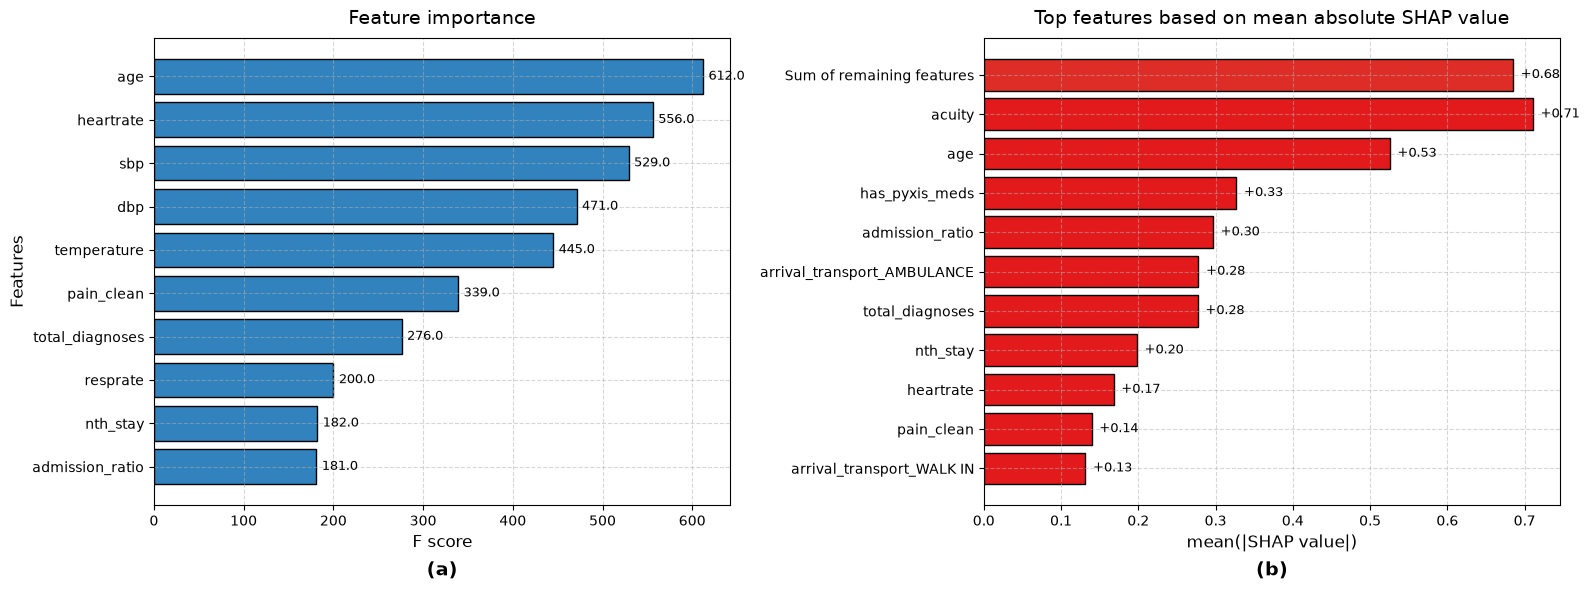

In [ ]:
# ==============================================================================
# 8.2 Generate Figure 2 (Feature Importance & SHAP Values for Admission)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from xgboost import XGBClassifier

# 1. Fit the best-performing XGBoost model on admission data
xgb_adm_model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_adm_model.fit(X_train_adm, y_train_adm)

display(pd.DataFrame)

# 2. Extract Intrinsic Feature Importance (F-score / Impurity Decrease)
booster = xgb_adm_model.get_booster()
score_dict = booster.get_score(importance_type='weight')  # F-score

# Sort and pick Top 10 features
sorted_scores = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:10]
features_fscore, scores_fscore = zip(*reversed(sorted_scores))

# 3. Calculate SHAP Values
explainer = shap.TreeExplainer(xgb_adm_model)
shap_values = explainer(X_test_adm)

# Calculate mean absolute SHAP values across all test instances
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X_test_adm.columns,
    'mean_shap': mean_abs_shap
}).sort_values(by='mean_shap', ascending=False)

top_10_shap = shap_importance_df.head(10).iloc[::-1]  # Reverse for horizontal plot
sum_other_shap = shap_importance_df.iloc[10:]['mean_shap'].sum()

# Combine Top 10 SHAP features with the sum of remaining features
shap_features = list(top_10_shap['feature']) + ['Sum of remaining features']
shap_values_plot = list(top_10_shap['mean_shap']) + [sum_other_shap]

# ==============================================================================
# PLOTTING FIGURE 2 SIDE-BY-SIDE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot (a): Intrinsic Feature Importance (F-score)
axes[0].barh(features_fscore, scores_fscore, color='#3182bd', edgecolor='black')
axes[0].set_title("Feature importance", fontsize=14, pad=10)
axes[0].set_xlabel("F score", fontsize=12)
axes[0].set_ylabel("Features", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Add numeric annotations to the end of bars
for i, v in enumerate(scores_fscore):
    axes[0].text(v + (max(scores_fscore) * 0.01), i, f"{v:.1f}", va='center', fontsize=9)

# Subplot (b): Top features based on mean absolute SHAP value
colors_shap = ['#e31a1c'] * len(top_10_shap) + ['#de2d26']
bars_b = axes[1].barh(shap_features, shap_values_plot, color=colors_shap, edgecolor='black')
axes[1].set_xlabel("mean(|SHAP value|)", fontsize=12)
axes[1].set_title("Top features based on mean absolute SHAP value", fontsize=14, pad=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Add numeric annotations to the end of bars
for i, v in enumerate(shap_values_plot):
    axes[1].text(v + 0.01, i, f"+{v:.2f}", va='center', fontsize=9)

# Annotate Figure (a) and (b) labels
axes[0].text(0.5, -0.15, "(a)", transform=axes[0].transAxes, fontsize=14, fontweight='bold', ha='center')
axes[1].text(0.5, -0.15, "(b)", transform=axes[1].transAxes, fontsize=14, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

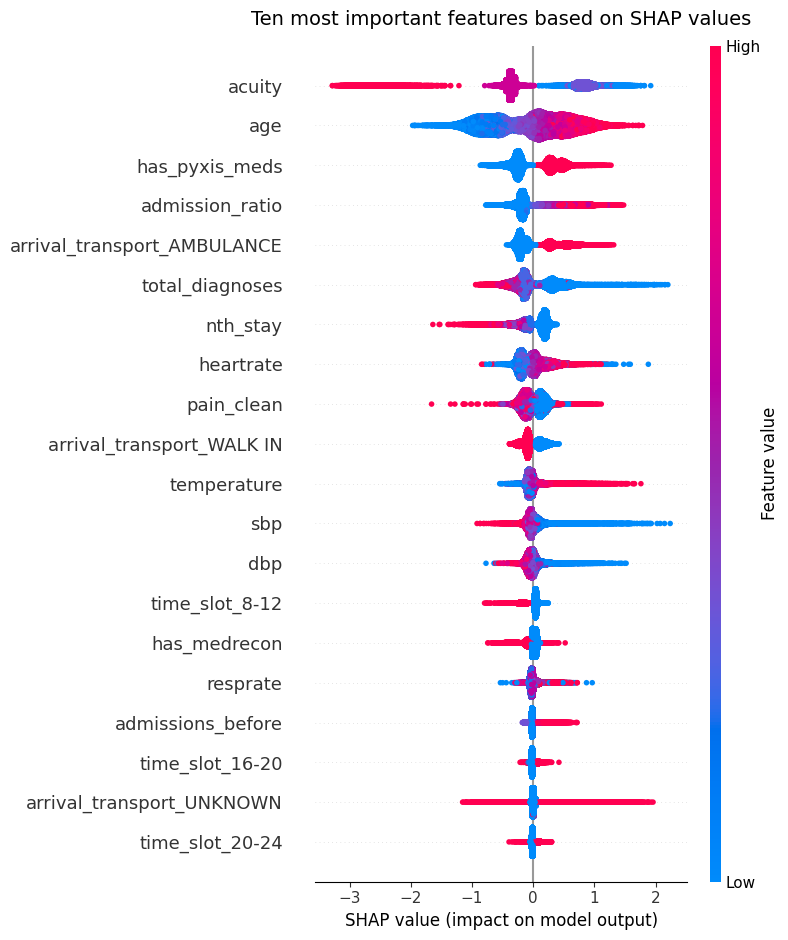

In [ ]:
# ==============================================================================
# 8.3 Generate Figure 3 (SHAP Summary Beeswarm Plot for Admission)
# ==============================================================================
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier

# 1. Fit XGBoost Model on Admission Data (if not already fit)
xgb_adm_model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_adm_model.fit(X_train_adm, y_train_adm)

# 2. Compute SHAP Values on Test Set
explainer = shap.TreeExplainer(xgb_adm_model)
shap_values = explainer(X_test_adm)

# 3. Filter/Select the Top 20 Most Important Features for Display
# (Computes mean absolute SHAP value per feature to rank top features)
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_feature_indices = np.argsort(mean_abs_shap)[::-1][:20]

# Subset SHAP values and feature names for top features
shap_values_top = shap_values[:, top_feature_indices]

# 4. Generate SHAP Beeswarm Summary Plot (Figure 3)
plt.figure(figsize=(8, 10))

shap.plots.beeswarm(
    shap_values_top,
    max_display=20,
    show=False
)

# Customizing plot title and labels matching Figure 3
plt.title("Ten most important features based on SHAP values", fontsize=14, pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

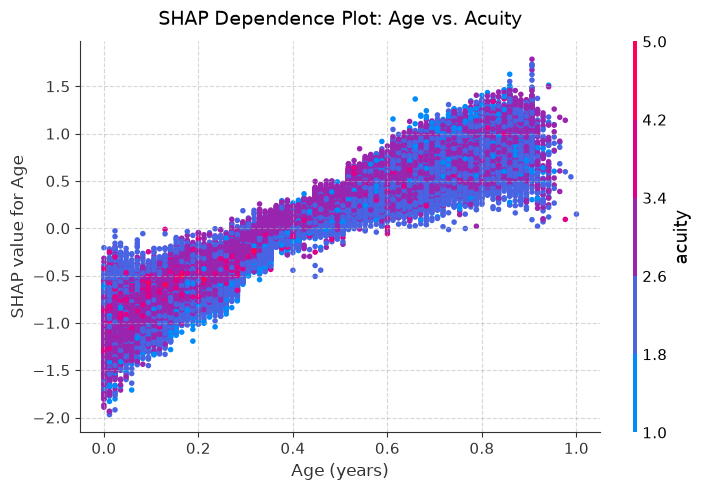

In [ ]:
# ==============================================================================
# 8.4 Generate Figure 6 (Dependence Plot: Age vs. Acuity)
# ==============================================================================
plt.figure(figsize=(8, 6))

shap.dependence_plot(
    "age",
    shap_values.values,
    X_test_adm,
    interaction_index="acuity",
    show=False
)

plt.title("SHAP Dependence Plot: Age vs. Acuity", fontsize=14, pad=12)
plt.xlabel("Age (years)", fontsize=12)
plt.ylabel("SHAP value for Age", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

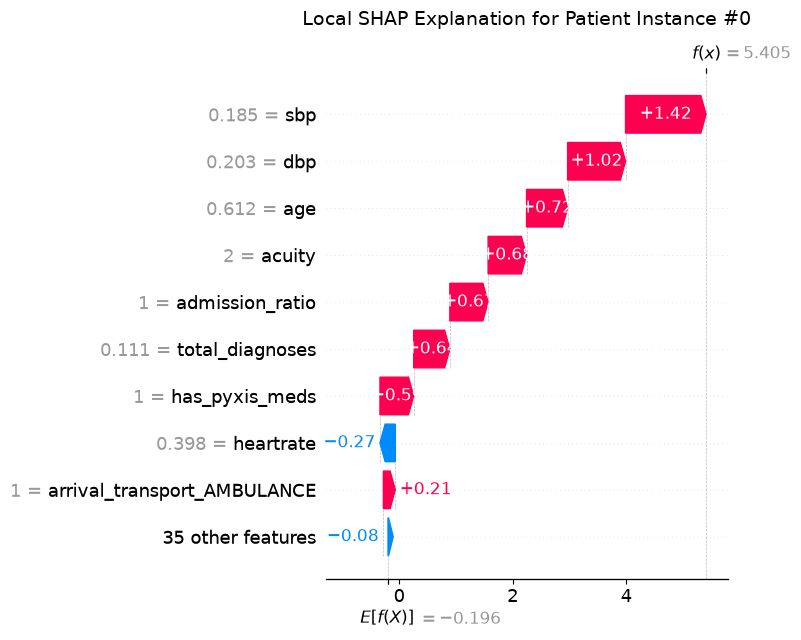

In [ ]:
# ==============================================================================
# 8.5 Generate Figure 7 (Local SHAP Explanation / Waterfall Plot)
# ==============================================================================
patient_idx = 0  # Select sample index from the test set

plt.figure(figsize=(9, 6))

shap.plots.waterfall(
    shap_values[patient_idx],
    max_display=10,
    show=False
)

plt.title(f"Local SHAP Explanation for Patient Instance #{patient_idx}", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

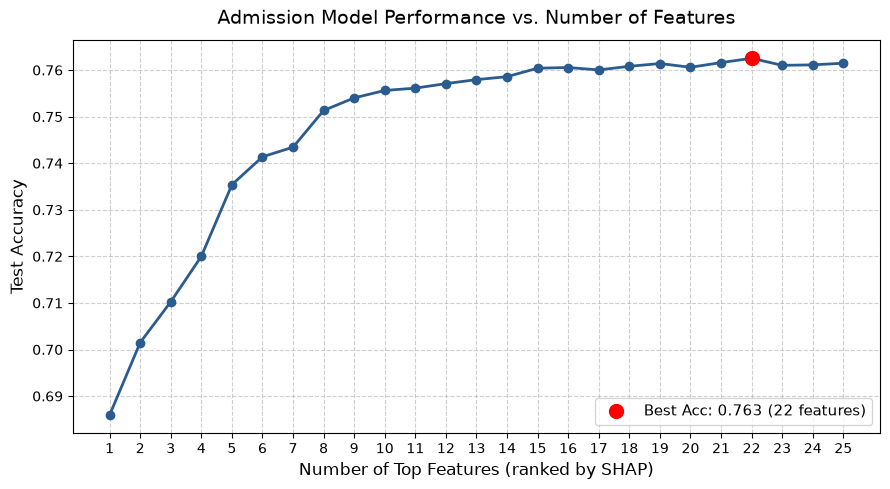

In [ ]:
# ==============================================================================
# 8.6: Generate Figure 8 (Accuracy vs. Number of Features Trade-off Curve)
# ==============================================================================
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Rank features based on SHAP importance
feature_rankings = shap_importance_df['feature'].tolist()

# 2. Iteratively train XGBoost model on top N features
feature_counts = range(1, min(26, len(feature_rankings) + 1))
accuracies = []

for k in feature_counts:
    top_k_features = feature_rankings[:k]

    clf = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
    clf.fit(X_train_adm[top_k_features], y_train_adm)

    preds = clf.predict(X_test_adm[top_k_features])
    acc = accuracy_score(y_test_adm, preds)
    accuracies.append(acc)

# 3. Plot Trade-off Curve (Figure 8)
plt.figure(figsize=(9, 5))
plt.plot(feature_counts, accuracies, marker='o', color='#2b5c8f', linewidth=2, markersize=6)

plt.title("Admission Model Performance vs. Number of Features", fontsize=14, pad=12)
plt.xlabel("Number of Top Features (ranked by SHAP)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.xticks(feature_counts)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight optimal trade-off point (knee point)
optimal_idx = np.argmax(accuracies)
plt.scatter(
    feature_counts[optimal_idx],
    accuracies[optimal_idx],
    color='red',
    s=100,
    zorder=5,
    label=f"Best Acc: {accuracies[optimal_idx]:.3f} ({feature_counts[optimal_idx]} features)"
)

plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

# PART B - PART B DATA EXPERIMENT REPORT

* Experiment 1: Refining the prediction of inpatient admission from emergency departments using MIMIC-IV-ED: A machine learning analysis.
* Experiment 2: training historical data and testing on latest stays (conducted data evaluation only, pending performance evaluation )
* Experiment 3: review of the combination of hadm-id and home disposition of 17% and how it may impact the model performance.
(pending)

# Experiment 1 : Using Grid Search Results to Optimize the Model

Refine previously reported tree-based classifier model to predict inpatient admission from the emergency department. Focusing on XGBoost as it the best comparative results (table 4).

In [ ]:
###############################################
# Experiment 1 - Gridsearch optimisation
###############################################
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
# Assuming X_train and y_train are already defined from your train_test_split

# 1. Define your model (using XGBoost from your existing imports)
model = XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')

# 2. Define the hyperparameter grid you want to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# 3. Configure Repeated 10-Fold Cross-Validation
# n_splits=10 for 10-fold, n_repeats is typically set to 3 or 5 for repeated CV
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

# 4. Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc', # You can change this to 'accuracy' or 'f1' based on your needs
    n_jobs=-1,         # Uses all available CPU cores for faster computation
    verbose=1          # Shows progress output
)

# 5. Execute the search on the training data
print("Starting Grid Search...")
grid_result = grid_search.fit(X_train_adm, y_train_adm)

# 6. Output the best results
print(f"Best ROC-AUC Score: {grid_result.best_score_:.4f}")
print(f"Best Parameters: {grid_result.best_params_}")

# To use the best model for predictions later:
best_xgb_model = grid_result.best_estimator_

import joblib

# Define a path to save the model in your Google Drive
model_save_path = data_dir / 'best_xgb_admission_model.joblib'

# Save the best model for reporting and later use
joblib.dump(best_xgb_model, model_save_path)
print(f"Optimized XGBoost model saved to: {model_save_path}")

### Loading the Saved optimisation Model (in case of rerun or colab new session)

In a fresh Colab session, after mounting your drive and defining `data_dir`, load the saved model:

In [ ]:
# Experiment 1 - Gridsearch optimisation
# Due to excssive execution time, the ouput of the gridsearch was saved and will be loaded from the data repository
import joblib

# Assuming 'data_dir' is already defined from your setup cells
model_load_path = data_dir / 'best_xgb_admission_model.joblib'

# Load the model
loaded_model = joblib.load(model_load_path)
print(f"Optimized XGBoost model loaded from: {model_load_path}")

# You can now use 'loaded_model' for predictions or further analysis
# For example, to make predictions with the loaded model:
# y_pred_loaded = loaded_model.predict(X_test_adm)
# print(f"Loaded Model Accuracy: {accuracy_score(y_test_adm, y_pred_loaded):.4f}")

Optimized XGBoost model loaded from: /content/drive/MyDrive/5005/A1/best_xgb_admission_model.joblib


In [ ]:
#########################################################
# Rerun the training with the optimized model parameters
#########################################################
import joblib

# Assuming 'data_dir' is already defined from your setup cells
model_load_path = data_dir / 'best_xgb_admission_model.joblib'

# Load the model
loaded_model = joblib.load(model_load_path)
print(f"Optimized XGBoost model loaded from: {model_load_path}")

# You can now use 'loaded_model' for predictions or further analysis
# For example, to make predictions with the loaded model:
y_pred_loaded = loaded_model.predict(X_test_adm)
print(f"Loaded Model Accuracy: {accuracy_score(y_test_adm, y_pred_loaded):.4f}")

# ==========================================
# STEP 4 Optimized: Model Training and Evaluation (Integrated)
# ==========================================
print("\n==========================================")
print("TASK 1b: Optimized Binary Hospital Admission Prediction")
print("==========================================")

X_train_adm, X_test_adm, y_train_adm, y_test_adm = train_test_split(
    X, y_admission, test_size=0.30, random_state=RANDOM_STATE, stratify=y_admission
)

# modify as per the gridsearch results
xgb_adm = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=7, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_adm.fit(X_train_adm, y_train_adm)
print(f"[XGBoost] Admission Accuracy: {accuracy_score(y_test_adm, xgb_adm.predict(X_test_adm)):.4f}")
print(f"[XGBoost] Admission AUROC:    {roc_auc_score(y_test_adm, xgb_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

# Adaboost increase estimators to 200
ada_adm = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
ada_adm.fit(X_train_adm, y_train_adm)
print(f"[AdaBoost] Admission Accuracy: {accuracy_score(y_test_adm, ada_adm.predict(X_test_adm)):.4f}")
print(f"[AdaBoost] Admission AUROC:    {roc_auc_score(y_test_adm, ada_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

print("\n==========================================")
print("TASK 2: Multiclass Disposition Ward Prediction")
print("==========================================")

admitted_idx = y_admission[y_admission == 1].index
X_res = X.loc[admitted_idx]
y_res = y_careunit.loc[admitted_idx]

unique_careunits = y_res.nunique()
print(f"Unique values in y_res for admitted patients: {y_res.value_counts()}")

if unique_careunits < 2:
    print("Skipping multiclass classification: Not enough unique careunit classes for admitted patients.")
else:
    labels, y_res_encoded = np.unique(y_res, return_inverse=True)

    X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
        X_res, y_res_encoded, test_size=0.30, random_state=RANDOM_STATE, stratify=y_res_encoded
    )

    xgb_res = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, objective='multi:softprob', eval_metric='mlogloss', random_state=RANDOM_STATE)
    xgb_res.fit(X_train_res, y_train_res)
    print(f"[XGBoost] Resource Macro F1: {f1_score(y_test_res, xgb_res.predict(X_test_res), average='macro'):.4f}")
    print(f"[XGBoost] Resource AUROC:    {roc_auc_score(y_test_res, xgb_res.predict_proba(X_test_res), multi_class='ovr'):.4f}")

Optimized XGBoost model loaded from: /content/drive/MyDrive/5005/A1/best_xgb_admission_model.joblib
Loaded Model Accuracy: 0.7628

TASK 1b: Optimized Binary Hospital Admission Prediction
[XGBoost] Admission Accuracy: 0.7628
[XGBoost] Admission AUROC:    0.8439
[AdaBoost] Admission Accuracy: 0.7471
[AdaBoost] Admission AUROC:    0.8254

TASK 2: Multiclass Disposition Ward Prediction
Unique values in y_res for admitted patients: careunit
General    135591
Name: count, dtype: int64
Skipping multiclass classification: Not enough unique careunit classes for admitted patients.


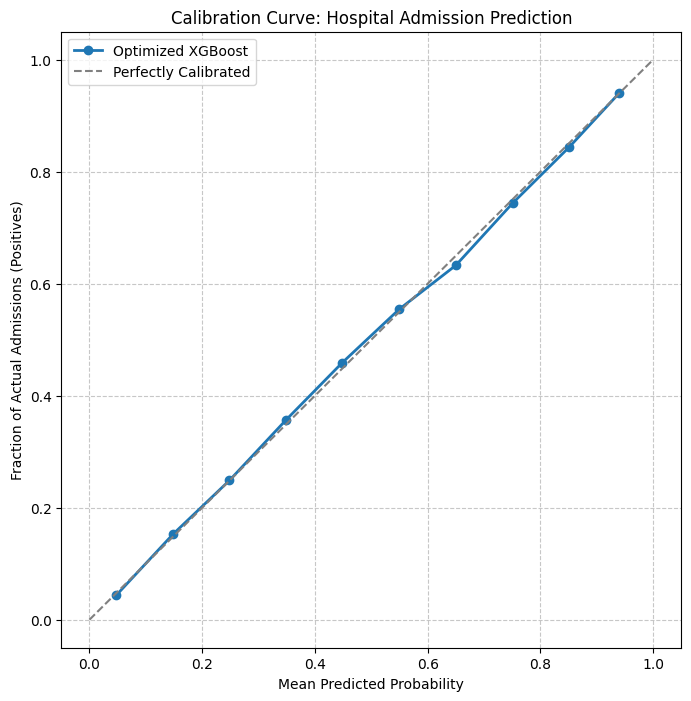

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# 1. Get predicted probabilities for the positive class (Admission)
y_pred_proba = xgb_adm.predict_proba(X_test_adm)[:, 1]

# 2. Compute the true fraction of positives and the mean predicted probabilities per bin
prob_true, prob_pred = calibration_curve(y_test_adm, y_pred_proba, n_bins=10)

# 3. Plot the calibration curve (Reliability Diagram)
plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Optimized XGBoost')

# Add the diagonal reference line for a perfectly calibrated model
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

# Formatting
plt.title('Calibration Curve: Hospital Admission Prediction')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Actual Admissions (Positives)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Experiment 2
Training on historical data; testing an latest stays in order to mimic real life admission assisted support:
* Admission decision is influenced by triage input, in combination with historical data of the same patient ( and/or Other patients with similar conditions)
* Reviewed by GP Specialist
* Subject to Bed availability and acuity


In [ ]:
# ==========================================
# Experiment 2: Model Training and Evaluation (Integrated) recent stays validation
# ==========================================
print("\n==========================================")
print("TASK 1: Binary Hospital Admission Prediction")
print("==========================================")

X_train_adm, X_test_adm, y_train_adm, y_test_adm = train_test_split(
    X, y_admission, test_size=0.30, random_state=RANDOM_STATE, stratify=y_admission
)

xgb_adm = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_adm.fit(X_train_adm, y_train_adm)
print(f"[XGBoost] Admission Accuracy: {accuracy_score(y_test_adm, xgb_adm.predict(X_test_adm)):.4f}")
print(f"[XGBoost] Admission AUROC:    {roc_auc_score(y_test_adm, xgb_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

ada_adm = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
ada_adm.fit(X_train_adm, y_train_adm)
print(f"[AdaBoost] Admission Accuracy: {accuracy_score(y_test_adm, ada_adm.predict(X_test_adm)):.4f}")
print(f"[AdaBoost] Admission AUROC:    {roc_auc_score(y_test_adm, ada_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

print("\n==========================================")
print("TASK 2: Multiclass Disposition Ward Prediction")
print("==========================================")

admitted_idx = y_admission[y_admission == 1].index
X_res = X.loc[admitted_idx]
y_res = y_careunit.loc[admitted_idx]

unique_careunits = y_res.nunique()
print(f"Unique values in y_res for admitted patients: {y_res.value_counts()}")

if unique_careunits < 2:
    print("Skipping multiclass classification: Not enough unique careunit classes for admitted patients.")
else:
    labels, y_res_encoded = np.unique(y_res, return_inverse=True)

    X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
        X_res, y_res_encoded, test_size=0.30, random_state=RANDOM_STATE, stratify=y_res_encoded
    )

    xgb_res = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, objective='multi:softprob', eval_metric='mlogloss', random_state=RANDOM_STATE)
    xgb_res.fit(X_train_res, y_train_res)
    print(f"[XGBoost] Resource Macro F1: {f1_score(y_test_res, xgb_res.predict(X_test_res), average='macro'):.4f}")
    print(f"[XGBoost] Resource AUROC:    {roc_auc_score(y_test_res, xgb_res.predict_proba(X_test_res), multi_class='ovr'):.4f}")


TASK 1: Binary Hospital Admission Prediction
[XGBoost] Admission Accuracy: 0.7625
[XGBoost] Admission AUROC:    0.8436
[AdaBoost] Admission Accuracy: 0.7442
[AdaBoost] Admission AUROC:    0.8219

TASK 2: Multiclass Disposition Ward Prediction
Unique values in y_res for admitted patients: careunit
General    135591
Name: count, dtype: int64
Skipping multiclass classification: Not enough unique careunit classes for admitted patients.
